all_dataframes.py loaded successfully
Base DataFrame loaded.

time_df created.


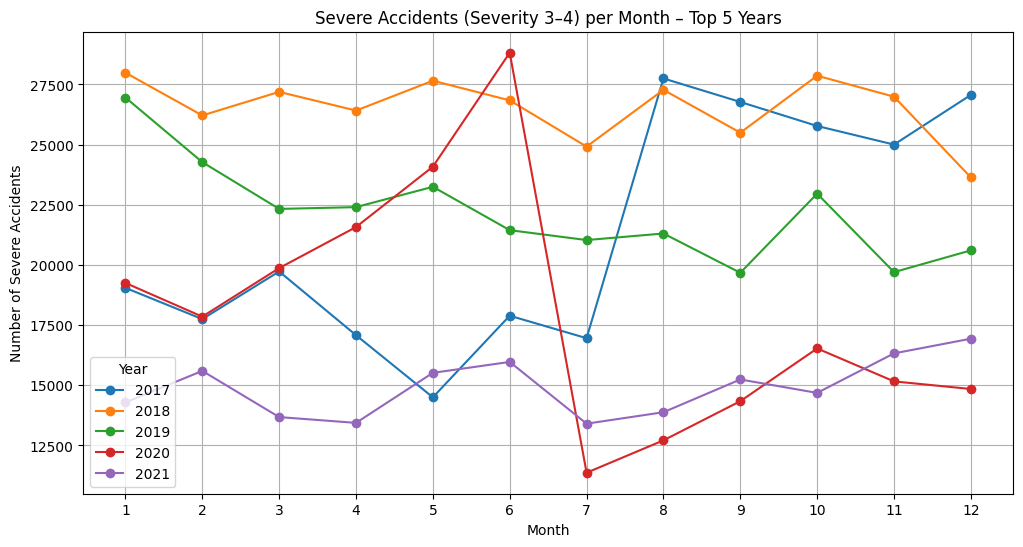

In [1]:
from pyspark.sql.functions import col, year, month
from all_dataframes import load_base_df, create_time_df
import matplotlib.pyplot as plt

df = load_base_df("C:/Users/serko/US_ACCIDENTS/US_Accidents_March23.csv")

time_df = create_time_df(df)


# Liitä Severity mukaan time_df:ään ja suodata vakavat onnettomuudet Severity 3,4
time_with_severity = time_df.join(
    df.select("ID", "Severity"),
    on="ID",
    how="left"
)

severe = time_with_severity.filter(col("Severity").isin(3, 4))

# Laske vakavat onnettomuudet vuosi- ja kuukausitasolla
monthly_counts = (
    severe
    .withColumn("year", year("Start_Time"))
    .withColumn("month", month("Start_Time"))
    .groupBy("year", "month")
    .count()
)

# 5 vuotta, joissa eniten vakavia onnettomuuksia
top5_years = (
    monthly_counts
    .groupBy("year")
    .sum("count")
    .orderBy(col("sum(count)").desc())
    .limit(5)
    .select("year")
)

filtered = monthly_counts.join(top5_years, on="year", how="inner")

# Muunna Pandas-muotoon visualisointia varten 
pdf = filtered.toPandas()

# visualisointi
plt.figure(figsize=(12, 6))

for year_value in sorted(pdf["year"].unique()):
    subset = pdf[pdf["year"] == year_value]
    subset=subset.sort_values("month")
    plt.plot(subset["month"], subset["count"], marker="o", label=str(year_value))

plt.title("Severe Accidents (Severity 3–4) per Month – Top 5 Years")
plt.xlabel("Month")
plt.ylabel("Number of Severe Accidents")
plt.xticks(range(1, 13))
plt.legend(title="Year")
plt.grid(True)
plt.show()

